# Downoload data

In [123]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("yasserh/titanic-dataset", output_dir="./data")

print("Path to dataset files:", path)

Path to dataset files: ./data


# 1. Load data

In [124]:
from pathlib import Path
import pandas as pd

DATA_DIR = Path("data")
DATA_FILE = DATA_DIR / "Titanic-Dataset.csv"

df = pd.read_csv(DATA_FILE)

df.head(7)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S


# 2. Data inspection

## 2.1 Basic information about the data 

In [125]:
print(df.shape)
print(df.columns)

print()

df.info()

(891, 12)
Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


### Observation
The dataset contains **891 passengers and 12 columns**. The `Survived` column is our target variable, while the remaining columns contain passenger characteristics and information that may be useful for predicting survival.

We can also see that there are missing values in the `Age`, `Cabin`, and `Embarked` columns. These missing values will need to be addressed during the data preprocessing stage.

## 2.2 Statistics for numerical variables

In [126]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


### Observation
From the numerical statistics, we can see that almost **62% of the passengers did not survive** the Titanic disaster.

The `Fare` variable is **right-skewed**, indicating that most passengers paid relatively low fares, while a small number of passengers paid significantly higher fares.

The statistics for `SibSp` and `Parch` suggest that most passengers **traveled without close family members** according to these variables.

More than **50% of the passengers were in the third class**, which indicates that third-class passengers represent the largest group in the dataset.


## 2.3 Categorical distributions

In [127]:
print(df["Sex"].value_counts())
print()
print(df["Embarked"].value_counts())
print()
print(df["Pclass"].value_counts())

Sex
male      577
female    314
Name: count, dtype: int64

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

Pclass
3    491
1    216
2    184
Name: count, dtype: int64


### Observation
The categorical distributions show that **men accounted for approximately two-thirds of the passengers, while women accounted for about one-third**.

Most passengers **embarked from Southampton**, making it the most common embarkation port. 

The **third class was also the largest passenger class** in the dataset.

# 3. Evaluate data analysis
Which features are associated with survival and can be useful for prediction?

## 3.1 Target distribution => survival distribution

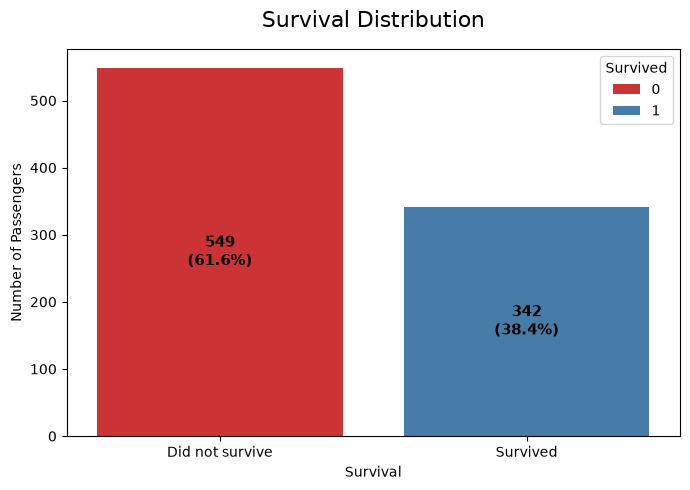

In [128]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

ax = sns.countplot(
    data=df,
    x="Survived",
    palette = "Set1",
    hue="Survived",
)

ax.set_title("Survival Distribution", fontsize=16, pad=16)
ax.set_xlabel("Survival")
ax.set_ylabel("Number of Passengers")

ax.set_xticks([0, 1])
ax.set_xticklabels(["Did not survive", "Survived"])

total = len(df)

# Place the number and precent of survived / not survived in the each plot
for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        percentage = height / total * 100

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height / 2,
            f"{int(height)}\n({percentage:.1f}%)",
            ha="center",
            va="center",
            fontsize=11,
            fontweight="bold"
        )
        
plt.tight_layout()
plt.show()

### Observation
More than 60% of the passengers does not survived the titanic disaster.

## 3.2 Categorical Features
- Survival distribution by sex
- Survival distribution by passenger class

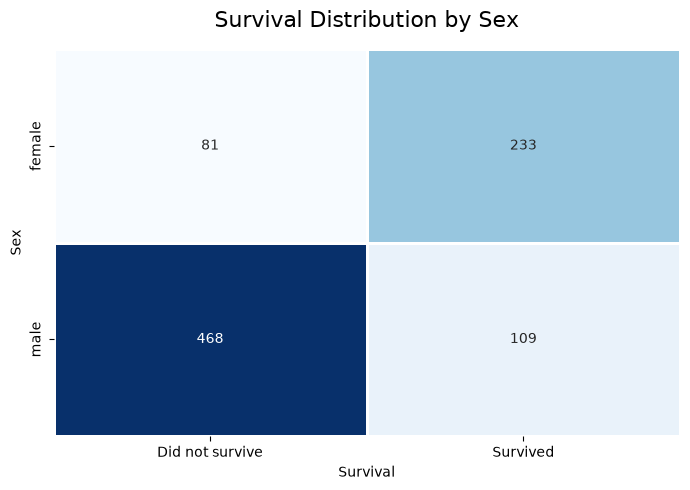

In [129]:
survival_by_sex = pd.crosstab(
    df["Sex"],
    df["Survived"]
)

survival_by_sex.columns = [
    "Did not survive",
    "Survived"
]

plt.figure(figsize=(7, 5))

ax = sns.heatmap(
    survival_by_sex,
    annot=True,
    fmt="d",
    linewidths=1,
    cbar=False,
    cmap='Blues'
)

ax.set_title(
    "Survival Distribution by Sex",
    fontsize=16,
    pad=16
)

ax.set_xlabel("Survival")
ax.set_ylabel("Sex")

plt.tight_layout()
plt.show()

### Observation
The survival rate differed substantially between male and female passengers. **Only approximately one in five male passengers survived the disaster, while nearly three out of four female passengers survived.** This represents a significant difference in survival rates between the two groups and suggests that `Sex` may be an important predictor of survival.

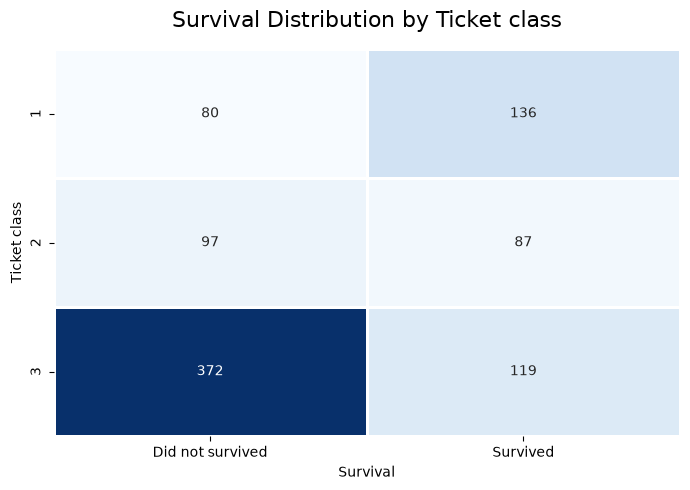

In [130]:
survival_by_pclass = pd.crosstab(
    df["Pclass"],
    df["Survived"]
)

survival_by_pclass.columns = [
    "Did not survived",
    "Survived"
]

plt.figure(figsize=(7, 5))

ax = sns.heatmap(
    survival_by_pclass,
    annot=True,
    fmt="d",
    linewidths=1,
    cbar=False,
    cmap="Blues"
)

ax.set_xlabel("Survival")
ax.set_ylabel("Ticket class")

ax.set_title(
    "Survival Distribution by Ticket class",
    fontsize=16,
    pad=16
)

plt.tight_layout()
plt.show()

### Observation
The survival rate varied substantially across passenger classes. **Only approximately one in five third-class passengers survived the disaster**, while the survival rate among second-class passengers was more balanced. In contrast, **first-class passengers had a substantially higher survival rate, with more passengers surviving than not surviving**.

These differences suggest that `Pclass` is **strongly associated with survival** and may represent an important predictive feature for the classification model.

## 3.3 Numerical Features
- Age distribution by survival
- Fare distribution by survival

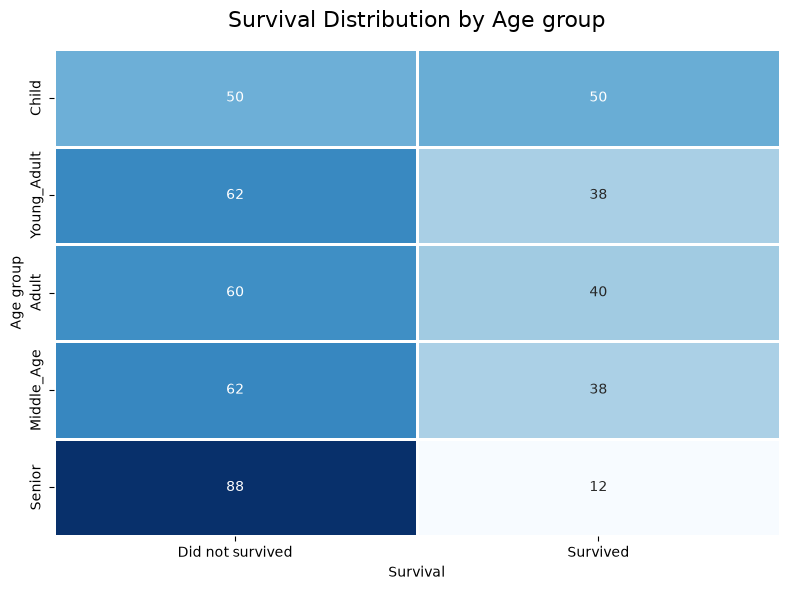

In [131]:
age_bins = [0, 18, 35, 50, 65, 80]

age_labels = [
    "Child",
    "Young_Adult",
    "Adult",
    "Middle_Age",
    "Senior"
]

eda_df = df.copy()

eda_df["AgeGroup"] = pd.cut(
    eda_df["Age"],
    bins=age_bins,
    labels=age_labels,
    include_lowest=True
)

survival_by_age = pd.crosstab(
    eda_df["AgeGroup"],
    eda_df["Survived"],
    normalize="index"
) * 100

survival_by_age.columns = [
    "Did not survived",
    "Survived"
]

plt.figure(figsize=(8, 6))

ax = sns.heatmap(
    survival_by_age,
    annot=True,
    linewidths=1,
    cbar=False,
    cmap="Blues"
)

ax.set_xlabel("Survival")
ax.set_ylabel("Age group")

ax.set_title(
    "Survival Distribution by Age group",
    fontsize=16,
    pad=16
)

plt.tight_layout()
plt.show()

### Observation
The survival rates show relatively small differences between the young adult, adult, and middle-aged groups. However, the child group shows a more noticeable difference, with a higher proportion of passengers surviving. 
The most substantial difference can be observed among senior passengers, where **only approximately one in ten passengers survived**.

These results suggest that age may be associated with survival, particularly among children and older passengers.

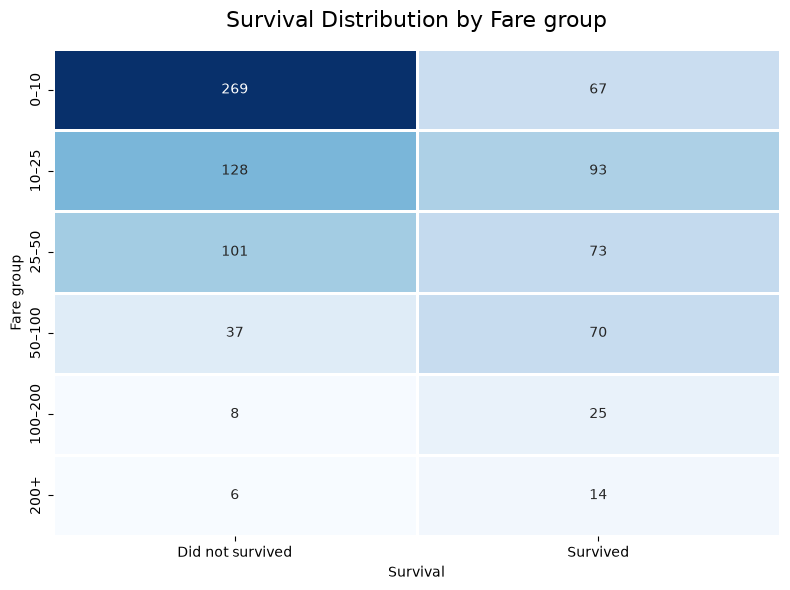

In [132]:
fare_bins = [0, 10, 25, 50, 100, 200, float("inf")]

fare_labels = [
    "0–10",
    "10–25",
    "25–50",
    "50–100",
    "100–200",
    "200+"
]

eda_df["FareGroup"] = pd.cut(
    eda_df["Fare"],
    bins=fare_bins,
    labels=fare_labels,
    include_lowest=True
)

survival_by_fare = pd.crosstab(
    eda_df["FareGroup"],
    eda_df["Survived"]
)

survival_by_fare.columns = [
    "Did not survived",
    "Survived"
]

plt.figure(figsize=(8, 6))

ax = sns.heatmap(
    survival_by_fare,
    annot=True,
    linewidths=1,
    cbar=False,
    cmap="Blues",
    fmt="d"
)

ax.set_xlabel("Survival")
ax.set_ylabel("Fare group")

ax.set_title(
    "Survival Distribution by Fare group",
    fontsize=16,
    pad=16
)

plt.tight_layout()
plt.show()

### Observation
The analysis shows a clear positive relationship between fare price and survival rate. Passengers who paid higher fares generally had a higher probability of survival, suggesting that fare price may be associated with socioeconomic status and could be an important predictor of survival.

# 4. Feature Engineering
- FamilySize => num
- IsAlone => (0/1)
- Title => (Ms, Mr, Miss, Mrs, Rare)
- Deck => (S, C, Q)
- drop unuse columns (PassengerId, Name, Ticket, Cabin)

## 4.1 Create new usefull features

In [133]:
# Add the numSiblings/numSposuses with numParents/numChilds
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
df["IsAlone"] = (df["FamilySize"] == 1).astype(int)


# Find the comma and the space and extract everything to the dot
df["Title"] = df["Name"].str.extract(r",\s*([^.]*)\.")

# Mlle/Ms = Miss and Mme = Mrs
df["Title"] = df["Title"].replace(
    ["Mlle", "Ms"],
    "Miss"
)

df["Title"] = df["Title"].replace(
    ["Mme"],
    "Mrs"
)

title_counts = df["Title"].value_counts()
rare_titles = title_counts[title_counts < 10].index

df["Title"] = df["Title"].replace(
    rare_titles,
    "Rare"
)


# Extract Deck information from Cabin => then Treat missing Cabin information as a separate category
df["Deck"] = df["Cabin"].str[0]
df["Deck"] = df["Deck"].fillna("Unknown")

## 4.2 Drop unuse columns

In [134]:
# Remove features that were replaced or are not useful for modeling
df = df.drop(columns=["PassengerId", "Name", "Cabin", "Ticket"])

# 5. Data preprocessing
- train/test split
- encoding categorical values (sex, embarked, pclass)
- handle missing values (age, embarked)

## 5.1 Split the data

In [135]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["Survived"])
y = df["Survived"]

# Stratify allow us to balance the target set (without stratify) => Train: (80% - 20%) and Test: (30% - 70%) 
# (with stratify) Train: (60% - 40%) and Test ~(60% - 40%)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (712, 11)
X_test: (179, 11)
y_train: (712,)
y_test: (179,)


## 5.2 Encode the categorical values

In [136]:
X_train = pd.get_dummies(
    X_train,
    columns=["Sex", "Embarked", "Title", "Deck"],
    drop_first=True
)

X_test = pd.get_dummies(
    X_test,
    columns=["Sex", "Embarked", "Title", "Deck"],
    drop_first=True
)

X_train, X_test = X_train.align(
    X_test,
    join="left",
    axis=1,
    fill_value=0
)

print(X_train.shape)
print(X_test.shape)

(712, 22)
(179, 22)
